# 🫀 Kalp Hastalığı Tahmini — Logistic Regression
**Veri Seti:** UCI Heart Disease Dataset  
**Hedef:** Kişinin kalp hastası olup olmadığını tahmin etmek (0 = Yok, 1 = Var)

## 1️⃣ Kütüphaneleri Yükle

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, roc_auc_score, roc_curve
)

print('Kütüphaneler başarıyla yüklendi ✅')

Kütüphaneler başarıyla yüklendi ✅


## 2️⃣ Veri Setini Yükle
UCI Heart Disease veri setini doğrudan URL'den çekiyoruz.

In [2]:
url = 'https://raw.githubusercontent.com/dsrscientist/dataset1/master/heart_disease.csv'
df = pd.read_csv(url)

# Sütun isimlerini Türkçeye çevirelim
df.columns = [
    'yas', 'cinsiyet', 'gogus_agrisi_tipi', 'dinlenim_kb',
    'kolesterol', 'aclik_sekeri', 'dinlenim_ekg',
    'maks_kalp_hizi', 'egzersiz_angina', 'st_depresyon',
    'st_egimi', 'damar_sayisi', 'talasemi', 'hedef'
]

print('Veri seti yüklendi! Boyut:', df.shape)
df.head()

Veri seti yüklendi! Boyut: (303, 14)


,yas,cinsiyet,gogus_agrisi_tipi,dinlenim_kb,kolesterol,aclik_sekeri,dinlenim_ekg,maks_kalp_hizi,egzersiz_angina,st_depresyon,st_egimi,damar_sayisi,talasemi,hedef
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 3️⃣ Veri Keşfi (EDA)

In [3]:
print('=== Genel Bilgi ===')
print(df.info())
print('\n=== Eksik Değer Kontrolü ===')
print(df.isnull().sum())
print('\n=== Hedef Sütun Dağılımı ===')
print(df['hedef'].value_counts())
print(f"\nHasta: {df['hedef'].sum()} | Sağlıklı: {(df['hedef']==0).sum()}")

=== Genel Bilgi ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   yas                303 non-null    int64  
 1   cinsiyet           303 non-null    int64  
 2   gogus_agrisi_tipi  303 non-null    int64  
 3   dinlenim_kb        303 non-null    int64  
 4   kolesterol         303 non-null    int64  
 5   aclik_sekeri       303 non-null    int64  
 6   dinlenim_ekg       303 non-null    int64  
 7   maks_kalp_hizi     303 non-null    int64  
 8   egzersiz_angina    303 non-null    int64  
 9   st_depresyon       303 non-null    float64
 10  st_egimi           303 non-null    int64  
 11  damar_sayisi       303 non-null    int64  
 12  talasemi           303 non-null    int64  
 13  hedef              303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None

=== Eksik Değer Kontrolü ===
yas                 

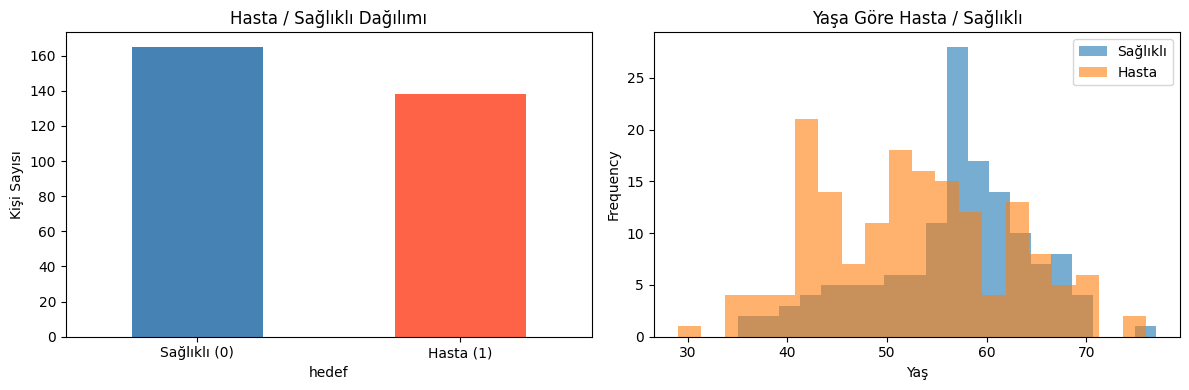

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Hedef dağılımı
df['hedef'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('Hasta / Sağlıklı Dağılımı')
axes[0].set_xticklabels(['Sağlıklı (0)', 'Hasta (1)'], rotation=0)
axes[0].set_ylabel('Kişi Sayısı')

# Yaş dağılımı
df.groupby('hedef')['yas'].plot(kind='hist', alpha=0.6, bins=20, ax=axes[1])
axes[1].set_title('Yaşa Göre Hasta / Sağlıklı')
axes[1].set_xlabel('Yaş')
axes[1].legend(['Sağlıklı', 'Hasta'])

plt.tight_layout()
plt.show()

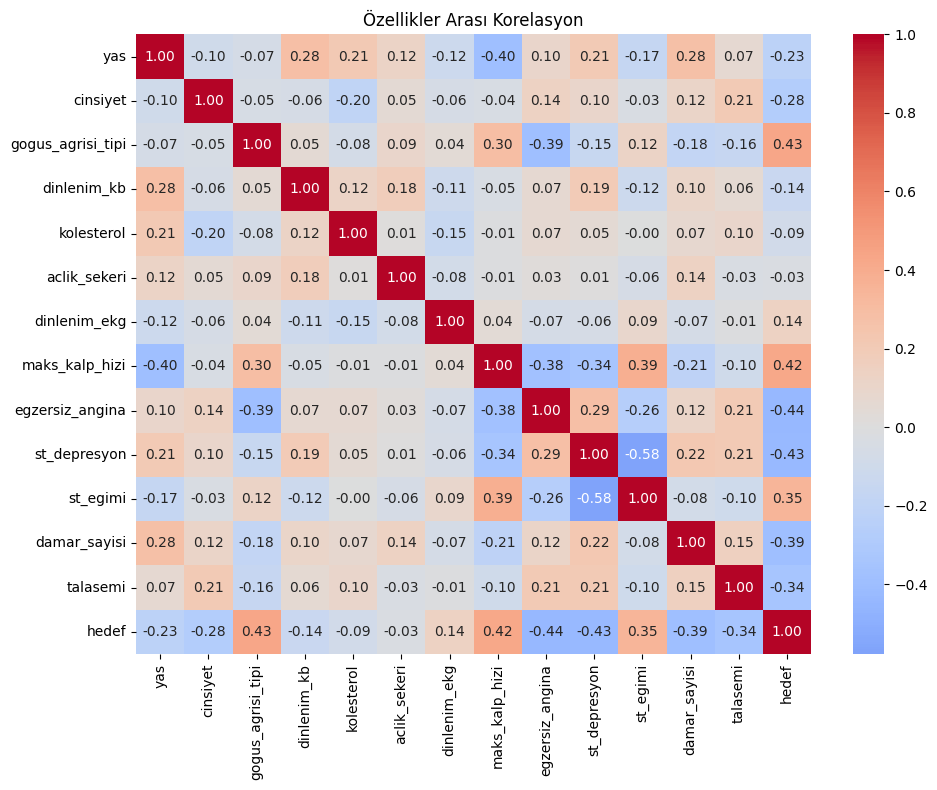

In [5]:
# Korelasyon ısı haritası
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Özellikler Arası Korelasyon')
plt.tight_layout()
plt.show()

## 4️⃣ Veriyi Hazırla

In [6]:
# Özellikler ve hedef
X = df.drop('hedef', axis=1)
y = df['hedef']

# Eğitim / Test bölümü (%80 eğitim, %20 test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Ölçeklendirme (Logistic Regression için önemli!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Eğitim seti: {X_train.shape[0]} örnek')
print(f'Test seti  : {X_test.shape[0]} örnek')

Eğitim seti: 242 örnek
Test seti  : 61 örnek


## 5️⃣ Modeli Eğit — Logistic Regression

In [7]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print('Model eğitildi ✅')

Model eğitildi ✅


## 6️⃣ Sonuçları Değerlendir

In [8]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f'Doğruluk (Accuracy) : %{acc*100:.1f}')
print(f'AUC Skoru           : {auc:.3f}')
print('\n=== Sınıflandırma Raporu ===')
print(classification_report(y_test, y_pred, target_names=['Sağlıklı', 'Hasta']))

Doğruluk (Accuracy) : %80.3
AUC Skoru           : 0.869

=== Sınıflandırma Raporu ===
              precision    recall  f1-score   support

    Sağlıklı       0.86      0.68      0.76        28
       Hasta       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61



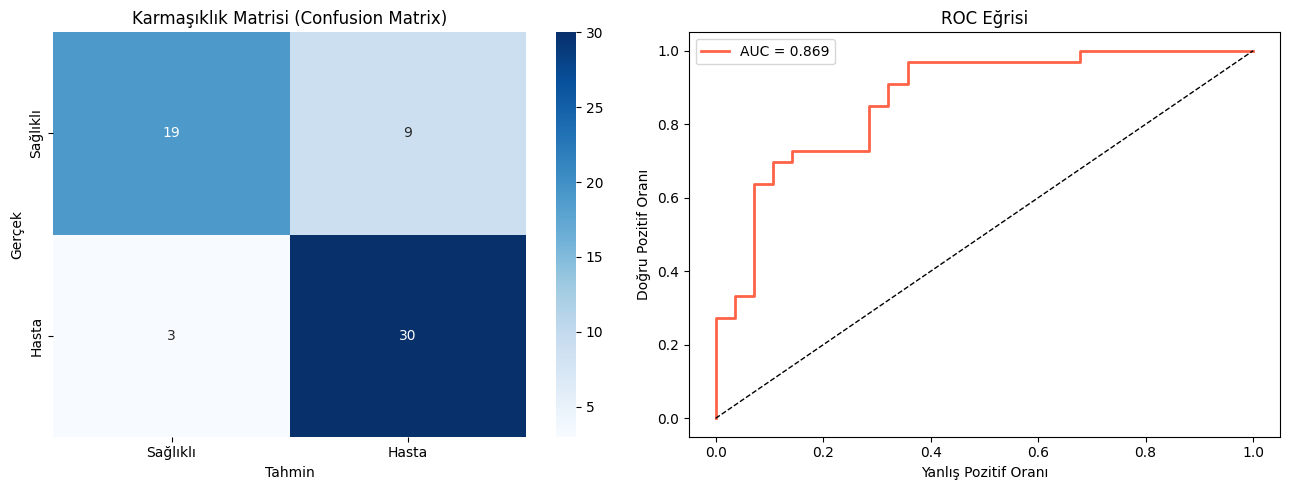

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Karmaşıklık matrisi
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Sağlıklı', 'Hasta'],
            yticklabels=['Sağlıklı', 'Hasta'])
axes[0].set_title('Karmaşıklık Matrisi (Confusion Matrix)')
axes[0].set_ylabel('Gerçek')
axes[0].set_xlabel('Tahmin')

# ROC eğrisi
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='tomato', lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0,1],[0,1], 'k--', lw=1)
axes[1].set_title('ROC Eğrisi')
axes[1].set_xlabel('Yanlış Pozitif Oranı')
axes[1].set_ylabel('Doğru Pozitif Oranı')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7️⃣ Hangi Özellik Ne Kadar Etkili?

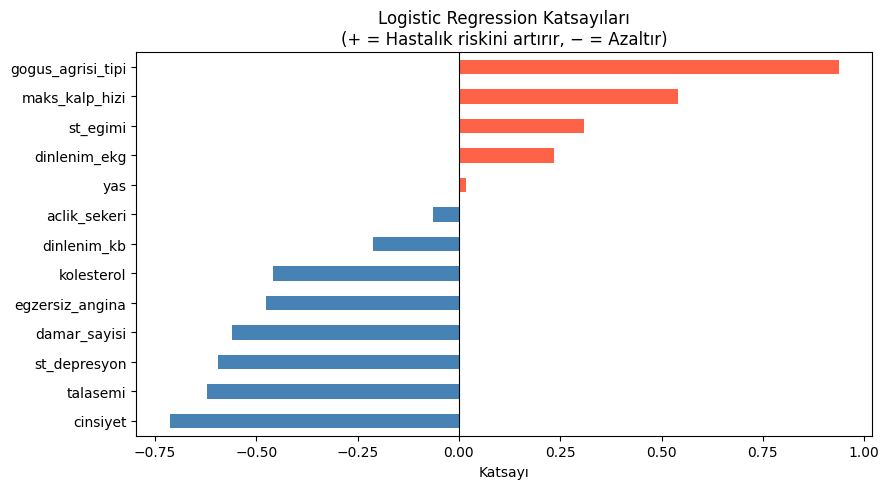

In [10]:
katsayilar = pd.Series(model.coef_[0], index=X.columns).sort_values()

plt.figure(figsize=(9, 5))
katsayilar.plot(kind='barh', color=['tomato' if v > 0 else 'steelblue' for v in katsayilar])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression Katsayıları\n(+ = Hastalık riskini artırır, − = Azaltır)')
plt.xlabel('Katsayı')
plt.tight_layout()
plt.show()

## 8️⃣ Yeni Bir Kişi İçin Tahmin Yap

In [11]:
# Örnek bir hasta verisi (istediğin değerleri değiştirebilirsin)
yeni_hasta = pd.DataFrame([{
    'yas': 55,
    'cinsiyet': 1,          # 1=Erkek, 0=Kadın
    'gogus_agrisi_tipi': 2,
    'dinlenim_kb': 130,
    'kolesterol': 250,
    'aclik_sekeri': 0,
    'dinlenim_ekg': 1,
    'maks_kalp_hizi': 150,
    'egzersiz_angina': 0,
    'st_depresyon': 1.5,
    'st_egimi': 2,
    'damar_sayisi': 0,
    'talasemi': 2
}])

yeni_scaled = scaler.transform(yeni_hasta)
tahmin = model.predict(yeni_scaled)[0]
olasilik = model.predict_proba(yeni_scaled)[0][1]

print(f'Tahmin      : {"🚨 HASTA" if tahmin == 1 else "✅ SAĞLIKLI"}')
print(f'Hastalık olasılığı: %{olasilik*100:.1f}')

Tahmin      : 🚨 HASTA
Hastalık olasılığı: %88.0
